# Análise Quantitativa de Conteúdo e Estrutura (RQ2)

Este notebook analisa os cabeçalhos extraídos dos arquivos de contexto de IA para identificar padrões de organização e os tópicos mais comuns abordados pelos desenvolvedores.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os

# Configuração visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# Carregar os dados extraídos
data_path = "../data/content_analysis/structure_analysis.csv"
df = pd.read_csv(data_path)

print(f"Total de cabeçalhos analisados: {len(df)}")
df.head()

Total de cabeçalhos analisados: 8129


,repo,file_type,level,title_original,title_normalized
0,elastic/elasticsearch,AGENTS.md,1,Elasticsearch,elasticsearch
1,elastic/elasticsearch,AGENTS.md,2,Toolchain Snapshot,toolchain snapshot
2,elastic/elasticsearch,AGENTS.md,2,Build & Run Commands,build run commands
3,elastic/elasticsearch,AGENTS.md,2,Verification & Lint Tasks,verification lint tasks
4,elastic/elasticsearch,AGENTS.md,2,Project Structure,project structure


## 1. Distribuição por Nível de Cabeçalho (Hierarquia)
Este gráfico mostra quão detalhadas são as instruções (Nível 1 são tópicos gerais, Níveis 2+ são detalhamentos).

/tmp/ipykernel_37851/1504511969.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='level', palette='viridis')


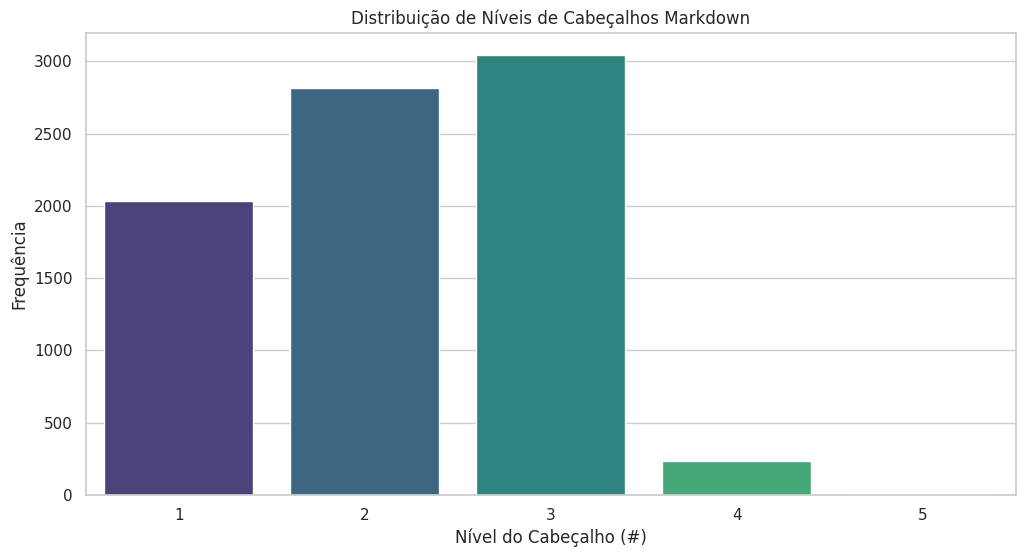

In [5]:
sns.countplot(data=df, x='level', palette='viridis')
plt.title('Distribuição de Níveis de Cabeçalhos Markdown')
plt.xlabel('Nível do Cabeçalho (#)')
plt.ylabel('Frequência')
plt.show()

## 2. Tópicos Mais Comuns (Nível 2)
Os cabeçalhos de nível 2 costumam representar as categorias principais de instruções (ex: Conventions, Setup, Testing).

/tmp/ipykernel_37851/1918510904.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_n2.values, y=top_n2.index, palette='magma')


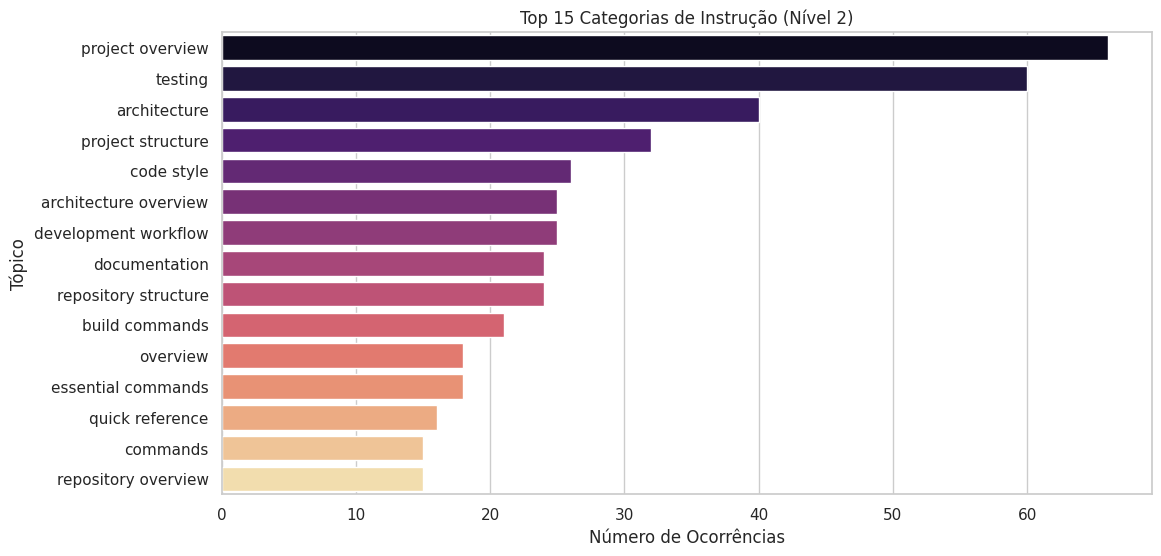

In [6]:
top_n2 = df[df['level'] == 2]['title_normalized'].value_counts().head(15)
sns.barplot(x=top_n2.values, y=top_n2.index, palette='magma')
plt.title('Top 15 Categorias de Instrução (Nível 2)')
plt.xlabel('Número de Ocorrências')
plt.ylabel('Tópico')
plt.show()

## 3. Comparação por Tipo de Arquivo
Será que o AGENTS.md e o CLAUDE.md focam em coisas diferentes?

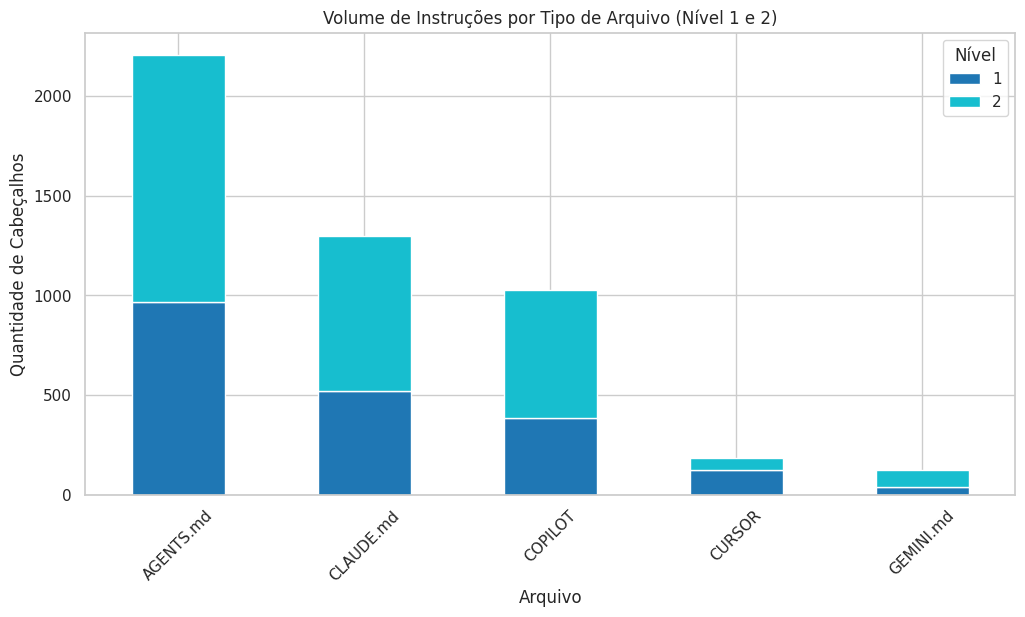

In [7]:
pivot_df = df[df['level'] <= 2].groupby(['file_type', 'level']).size().unstack(fill_value=0)
pivot_df.plot(kind='bar', stacked=True, colormap='tab10')
plt.title('Volume de Instruções por Tipo de Arquivo (Nível 1 e 2)')
plt.xlabel('Arquivo')
plt.ylabel('Quantidade de Cabeçalhos')
plt.xticks(rotation=45)
plt.legend(title='Nível')
plt.show()